In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import re

In [2]:
df = pd.read_csv("complete_results.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5010 entries, 0 to 5009
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   name                     5010 non-null   object 
 1   main_category            5010 non-null   object 
 2   sub_category             5010 non-null   object 
 3   image                    5010 non-null   object 
 4   link                     5010 non-null   object 
 5   no_of_ratings            4976 non-null   object 
 6   discount_price           4740 non-null   object 
 7   actual_price             4979 non-null   object 
 8   review_rating            5010 non-null   object 
 9   original_review_text     5007 non-null   object 
 10  bart_summary             5007 non-null   object 
 11  bart_rouge1              5010 non-null   float64
 12  bart_rouge2              5010 non-null   float64
 13  bart_rougeL              5010 non-null   float64
 14  bart_avg_rouge          

In [3]:
df = df[['name','main_category','sub_category','no_of_ratings','discount_price','actual_price','review_rating','cleaned_narrative']]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5010 entries, 0 to 5009
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   name               5010 non-null   object
 1   main_category      5010 non-null   object
 2   sub_category       5010 non-null   object
 3   no_of_ratings      4976 non-null   object
 4   discount_price     4740 non-null   object
 5   actual_price       4979 non-null   object
 6   review_rating      5010 non-null   object
 7   cleaned_narrative  5010 non-null   object
dtypes: object(8)
memory usage: 313.3+ KB


In [4]:
df.describe()

,name,main_category,sub_category,no_of_ratings,discount_price,actual_price,review_rating,cleaned_narrative
count,5010,5010,5010,4976,4740,4979,5010,5010
unique,4613,1,1,2564,1033,744,5,5008
top,TAGG Verve Sense Smartwatch with 1.70'' Large ...,"tv, audio & cameras",All Electronics,FREE Delivery by Amazon,₹299,₹999,5.0 out of 5 stars,No customer review available for this product.
freq,7,5010,5010,18,229,656,3731,3


In [5]:
df
# df[df['discount_price'].isnull()]


,name,main_category,sub_category,no_of_ratings,discount_price,actual_price,review_rating,cleaned_narrative
0,"Redmi 10 Power (Power Black, 8GB RAM, 128GB St...","tv, audio & cameras",All Electronics,965,"₹10,999","₹18,999",3.0 out of 5 stars,"""The customer mentioned that while they found ..."
1,"OnePlus Nord CE 2 Lite 5G (Blue Tide, 6GB RAM,...","tv, audio & cameras",All Electronics,"113,956","₹18,999","₹19,999",1.0 out of 5 stars,The customer mentioned their extremely negativ...
2,OnePlus Bullets Z2 Bluetooth Wireless in Ear E...,"tv, audio & cameras",All Electronics,"90,304","₹1,999","₹2,299",5.0 out of 5 stars,"""The customer was thoroughly impressed with th..."
3,"Samsung Galaxy M33 5G (Mystique Green, 6GB, 12...","tv, audio & cameras",All Electronics,"24,863","₹15,999","₹24,999",1.0 out of 5 stars,The customer mentioned that the Face ID featur...
4,"OnePlus Nord CE 2 Lite 5G (Black Dusk, 6GB RAM...","tv, audio & cameras",All Electronics,"113,956","₹18,999","₹19,999",5.0 out of 5 stars,The customer mentioned that they were previous...
...,...,...,...,...,...,...,...,...
5005,"ASUS MD100 Marshmallow/Silent, Adj. DPI, Multi...","tv, audio & cameras",All Electronics,NaN,"₹1,499","₹2,999",5.0 out of 5 stars,The customer mentioned that they are extremely...
5006,Crysendo Headphone Cushion Pad Compatible with...,"tv, audio & cameras",All Electronics,231,₹499,₹849,5.0 out of 5 stars,"""The customer mentioned, ""Nothing,"" which succ..."
5007,"VOYEE Controller for PC, Wired Gamepad, Gaming...","tv, audio & cameras",All Electronics,85,₹699,"₹1,999",4.0 out of 5 stars,No customer review available for this product.
5008,boAt Airdopes 393ANC True Wireless in Ear Earb...,"tv, audio & cameras",All Electronics,67,"₹2,299","₹4,990",5.0 out of 5 stars,No customer review available for this product.


# Checking Null values

In [6]:
df.isnull().sum()

name                   0
main_category          0
sub_category           0
no_of_ratings         34
discount_price       270
actual_price          31
review_rating          0
cleaned_narrative      0
dtype: int64

# Sentiment Distribution

In [7]:
df['review_rating'] = df['review_rating'].str.extract('(\d+\.\d+)').astype(float)
def get_sentiment(rating):
    if rating <= 2:
        return "Negative Review"
    elif rating == 3:
        return "Neutral Review"
    else:
        return "Positive Review"

df['sentiment'] = df['review_rating'].apply(get_sentiment)
df['sentiment'].value_counts()

sentiment
Positive Review    4451
Negative Review     406
Neutral Review      153
Name: count, dtype: int64

In [8]:
df['review_rating'].value_counts()

review_rating
5.0    3731
4.0     720
1.0     319
3.0     153
2.0      87
Name: count, dtype: int64

# Filling Missing Values

In [9]:
#  no of rating
df['no_of_ratings'] = df['no_of_ratings'].str.replace(',','')
df['no_of_ratings'] = pd.to_numeric(df['no_of_ratings'], errors='coerce').astype('Int64')
df['no_of_ratings'].fillna(df['no_of_ratings'].median(), inplace=True)

# discount price
df['discount_price'] = df['discount_price'].str.replace('₹','')
df['discount_price'] = df['discount_price'].str.replace(',','')
df['discount_price'] = pd.to_numeric(df['discount_price'], errors='coerce')
df['discount_price'].fillna(df['discount_price'].median(), inplace=True)

# actual price
df['actual_price'] = df['actual_price'].str.replace('₹','')
df['actual_price'] = df['actual_price'].str.replace(',','')
df['actual_price'] = pd.to_numeric(df['actual_price'], errors='coerce')
df['actual_price'].fillna(df['actual_price'].median(), inplace=True)


In [10]:
df['cleaned_narrative'] = df['cleaned_narrative'].str.replace(
    r"The customer mentioned |The reviewer noted ",
    "",
    regex=True
)

In [11]:
noise_words = [
    "customer", "reviewer", "mentioned", "noted",
    "highlighted", "stated", "reported"
]

def clean_text(text):
    text = text.lower()
    
    # remove noise words safely
    for word in noise_words:
        text = re.sub(r'\b' + word + r'\b', '', text)
    
    # remove special characters
    text = re.sub('[^a-zA-Z]', ' ', text)
    
    # remove extra spaces
    text = re.sub('\s+', ' ', text).strip()
    
    return text

df['cleaned_narrative'] = df['cleaned_narrative'].apply(clean_text)

In [12]:
generic_words = ['product', 'device', 'feature']

def remove_generic(text):
    for word in generic_words:
        text = re.sub(r'\b' + word + r'\b', '', text)
    return text

df['cleaned_narrative'] = df['cleaned_narrative'].apply(remove_generic)

In [13]:
df.iloc[23]

name                 OnePlus 11R 5G (Galactic Silver, 16GB RAM, 256...
main_category                                      tv, audio & cameras
sub_category                                           All Electronics
no_of_ratings                                                      338
discount_price                                                   649.0
actual_price                                                   44999.0
review_rating                                                      5.0
cleaned_narrative    that they are highly satisfied with their onep...
sentiment                                              Positive Review
Name: 23, dtype: object

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5010 entries, 0 to 5009
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               5010 non-null   object 
 1   main_category      5010 non-null   object 
 2   sub_category       5010 non-null   object 
 3   no_of_ratings      5010 non-null   Int64  
 4   discount_price     5010 non-null   float64
 5   actual_price       5010 non-null   float64
 6   review_rating      5010 non-null   float64
 7   cleaned_narrative  5010 non-null   object 
 8   sentiment          5010 non-null   object 
dtypes: Int64(1), float64(3), object(5)
memory usage: 357.3+ KB


In [15]:
df

,name,main_category,sub_category,no_of_ratings,discount_price,actual_price,review_rating,cleaned_narrative,sentiment
0,"Redmi 10 Power (Power Black, 8GB RAM, 128GB St...","tv, audio & cameras",All Electronics,965,10999.0,18999.0,3.0,that while they found the redmi power s design...,Neutral Review
1,"OnePlus Nord CE 2 Lite 5G (Blue Tide, 6GB RAM,...","tv, audio & cameras",All Electronics,113956,18999.0,19999.0,1.0,their extremely negative experience with the o...,Negative Review
2,OnePlus Bullets Z2 Bluetooth Wireless in Ear E...,"tv, audio & cameras",All Electronics,90304,1999.0,2299.0,5.0,the was thoroughly impressed with the oneplus ...,Positive Review
3,"Samsung Galaxy M33 5G (Mystique Green, 6GB, 12...","tv, audio & cameras",All Electronics,24863,15999.0,24999.0,1.0,that the face id on their samsung galaxy m g ...,Negative Review
4,"OnePlus Nord CE 2 Lite 5G (Black Dusk, 6GB RAM...","tv, audio & cameras",All Electronics,113956,18999.0,19999.0,5.0,that they were previously an android user but ...,Positive Review
...,...,...,...,...,...,...,...,...,...
5005,"ASUS MD100 Marshmallow/Silent, Adj. DPI, Multi...","tv, audio & cameras",All Electronics,2321,1499.0,2999.0,5.0,that they are extremely satisfied with the asu...,Positive Review
5006,Crysendo Headphone Cushion Pad Compatible with...,"tv, audio & cameras",All Electronics,231,499.0,849.0,5.0,the nothing which succinctly encapsulates thei...,Positive Review
5007,"VOYEE Controller for PC, Wired Gamepad, Gaming...","tv, audio & cameras",All Electronics,85,699.0,1999.0,4.0,no review available for this,Positive Review
5008,boAt Airdopes 393ANC True Wireless in Ear Earb...,"tv, audio & cameras",All Electronics,67,2299.0,4990.0,5.0,no review available for this,Positive Review


# Sentiment Distribution

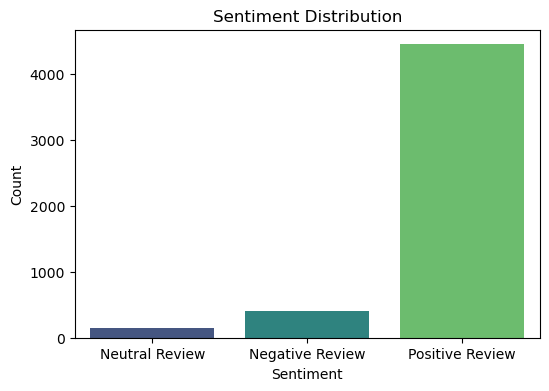

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df, palette='viridis')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

# Rating Distribution

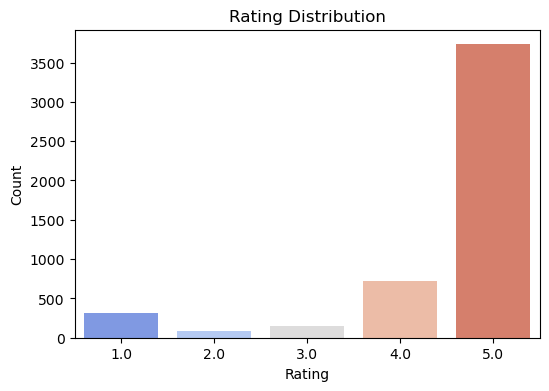

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x='review_rating', data=df, palette='coolwarm')

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

# Sentiment vs Rating

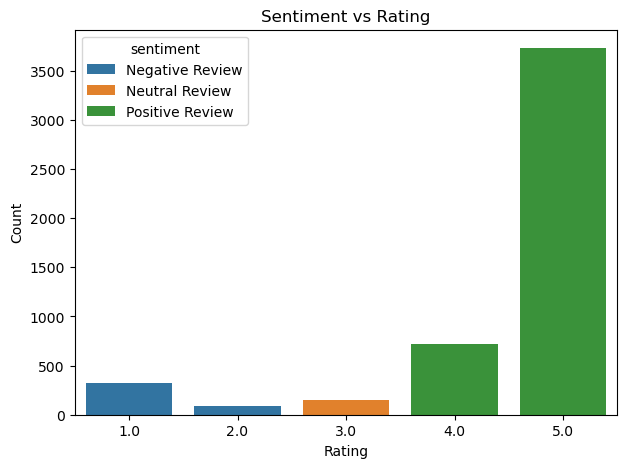

In [18]:
plt.figure(figsize=(7,5))
sns.countplot(x='review_rating', hue='sentiment', data=df)

plt.title("Sentiment vs Rating")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

In [19]:
df['main_category'].unique()

array(['tv, audio & cameras'], dtype=object)

# Top Category Distribution

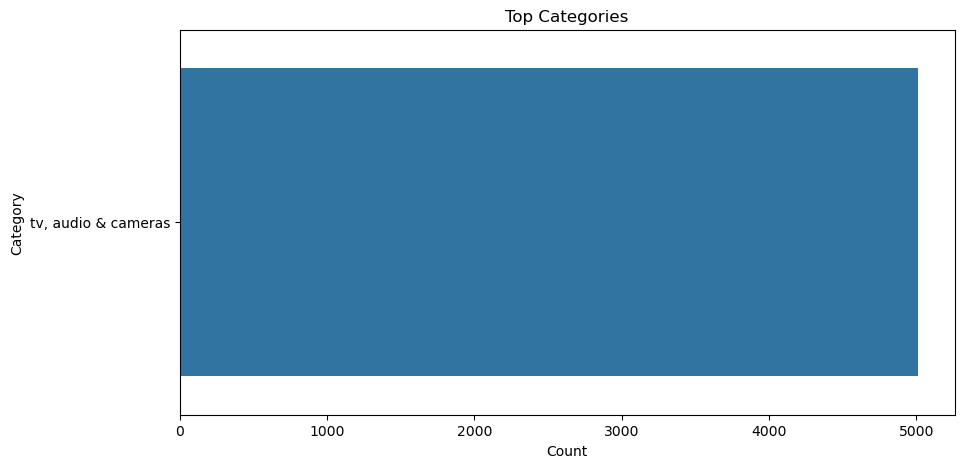

In [20]:
plt.figure(figsize=(10,5))

top_cat = df['main_category'].value_counts().head(10)

sns.barplot(x=top_cat.values, y=top_cat.index)

plt.title("Top Categories")
plt.xlabel("Count")
plt.ylabel("Category")

plt.show()

# Word Cloud for all reviews

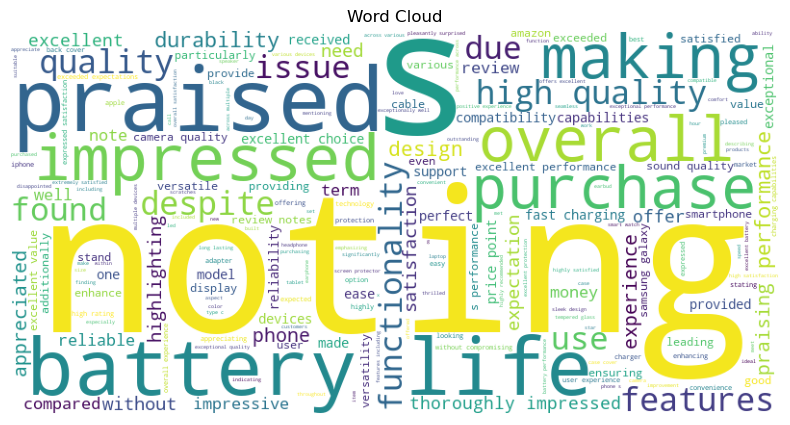

In [21]:
text = " ".join(df['cleaned_narrative'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")

plt.title("Word Cloud")

plt.show()

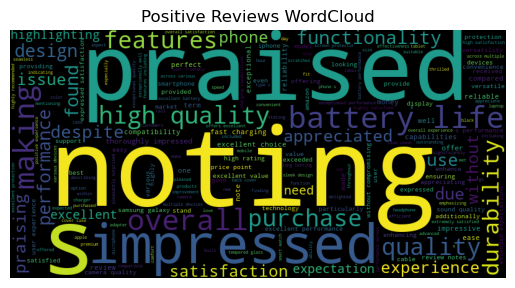

In [22]:
positive_text = " ".join(df[df['sentiment']=='Positive Review']['cleaned_narrative'])

wc = WordCloud(width=800, height=400).generate(positive_text)

plt.imshow(wc)
plt.axis("off")
plt.title("Positive Reviews WordCloud")

plt.show()

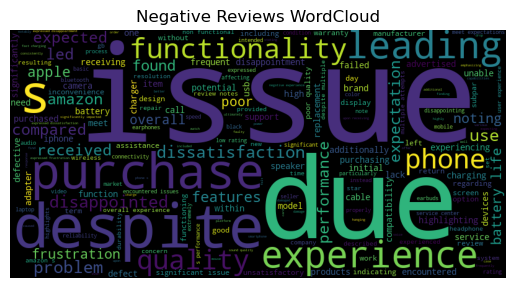

In [23]:
negative_text = " ".join(df[df['sentiment']=='Negative Review']['cleaned_narrative'])

wc = WordCloud(width=800, height=400).generate(negative_text)

plt.imshow(wc)
plt.axis("off")
plt.title("Negative Reviews WordCloud")

plt.show()

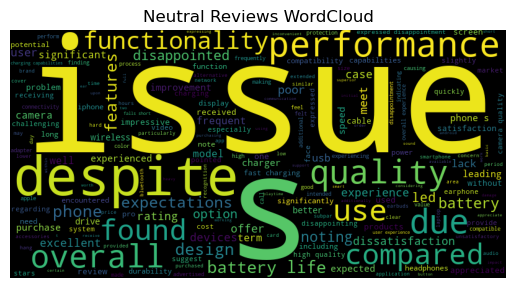

In [24]:
neutral_text = " ".join(df[df['sentiment']=='Neutral Review']['cleaned_narrative'])

wc = WordCloud(width=800, height=400).generate(neutral_text)

plt.imshow(wc)
plt.axis("off")
plt.title("Neutral Reviews WordCloud")

plt.show()

# Data Preprocessing

In [25]:
# Features and Target
X = df['cleaned_narrative']
y = df['sentiment']

In [26]:
# Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
X_test

427     that they are extremely satisfied with the pur...
4011    the was thoroughly impressed by the maono au a...
2351    that the sony ht s r real ch dolby audio sound...
4016    the praised the wide compatibility of ambrane ...
1178    the was delighted with their purchase of the l...
                              ...                        
1388    that the orico inch external hard drive enclos...
655     they have been addicted to apple products but ...
3941    the praised the amazon basics foot micro hdmi ...
2337    the was thrilled with their purchase of the le...
2033    that their phone s functionality has been comp...
Name: cleaned_narrative, Length: 1002, dtype: object

# Text Vectorization (NLP)

In [52]:
STRONG_NEGATIVE_PHRASES = [
    # value / money
    "waste of money", "not worth", "not worth the price",
    "not worth buying", "total waste", "complete waste",
    "waste of time", "rip off", "ripoff", "overpriced",
    # quality
    "very poor", "very bad", "really bad", "extremely bad",
    "poor build quality", "build quality is poor", "very poor build",
    "poor quality", "low quality", "terrible quality", "horrible quality",
    # usability
    "completely useless", "totally useless", "absolutely useless",
    "does not work", "doesnt work", "stopped working", "stopped work",
    "broke after", "dead on arrival", "doa",
    # regret / recommendation
    "do not buy", "dont buy", "don't buy", "avoid this", "avoid at all costs",
    "would not recommend", "wouldn't recommend", "cannot recommend",
    "returning this", "returned this", "asked for refund",
    # dissatisfaction
    "deeply disappointed", "very disappointed", "extremely disappointed",
    "not happy", "not satisfied", "not pleased",
    "biggest mistake", "worst purchase", "worst decision", "worst product",
    # other
    "not good at all", "not great at all", "absolutely terrible",
    "absolutely horrible", "absolutely awful",
]

# ── Strong-negative single words ──────────────────────────────────────────
STRONG_NEGATIVE_WORDS = {
    "useless", "worthless", "garbage", "junk", "trash", "rubbish",
    "hate", "hated", "awful", "terrible", "horrible", "dreadful",
    "worst", "atrocious", "abysmal", "appalling",
    "broken", "defective", "faulty", "fraudulent", "scam",
    "disappointing", "disappointed", "disgusted", "regret",
    "unusable", "malfunctioning", "pathetic", "disastrous",
}

# ── Regular-negative (used in keyword fallback) ───────────────────────────
NEGATIVE_WORDS = STRONG_NEGATIVE_WORDS | {
    "bad", "poor", "slow", "cheap", "flimsy", "fragile", "unreliable",
    "issue", "problem", "failure", "fail", "failed", "fails",
    "uncomfortable", "annoying", "frustrating", "frustration",
    "inadequate", "inferior", "mediocre", "deficient",
    "damage", "damaged", "scratch", "scratched", "broken",
}

# ── Negation words ────────────────────────────────────────────────────────
NEGATION_WORDS = {
    "not", "no", "never", "neither", "nor", "without",
    "cant", "cannot", "wont", "dont", "doesnt",
    "didn't", "doesn't", "won't", "can't", "don't", "isn't",
    "wasn't", "aren't", "weren't", "haven't", "hasn't",
    "couldn't", "wouldn't", "shouldn't",
}

# ── Strong-positive phrases ───────────────────────────────────────────────
STRONG_POSITIVE_PHRASES = [
    "absolutely love", "really love", "totally love",
    "highly recommend", "strongly recommend",
    "exceeded expectations", "beyond expectations", "exceeds expectations",
    "best purchase", "best product", "best buy",
    "very happy", "extremely happy", "very satisfied", "extremely satisfied",
    "works perfectly", "works great", "works flawlessly",
    "absolutely amazing", "absolutely fantastic", "absolutely brilliant",
    "great value", "great quality", "excellent quality", "excellent value",
    "worth every penny", "worth the price", "well worth",
    "very impressed", "really impressed", "extremely impressed",
    "best ever", "love this product", "love this item",
]

# ── Strong-positive single words ─────────────────────────────────────────
STRONG_POSITIVE_WORDS = {
    "excellent", "outstanding", "superb", "brilliant", "wonderful",
    "fantastic", "amazing", "awesome", "perfect", "flawless",
    "love", "loved", "recommend",
}

# ── Regular-positive ─────────────────────────────────────────────────────
POSITIVE_WORDS = STRONG_POSITIVE_WORDS | {
    "good", "great", "nice", "satisfied", "happy", "pleased",
    "comfortable", "reliable", "durable", "solid", "efficient",
    "effective", "helpful", "useful", "convenient", "impressive",
    "delightful", "enjoy", "enjoyed", "quality",
}

# ── Neutral ───────────────────────────────────────────────────────────────
NEUTRAL_WORDS = {
    "okay", "ok", "average", "fine", "decent", "normal",
    "moderate", "acceptable", "ordinary", "fair", "alright",
    "standard", "basic",
}

NEUTRAL_PHRASES = [
    "nothing special", "not bad", "does the job", "works fine",
    "could be better", "could be worse", "meets expectations",
    "as expected", "as described", "neither good nor bad",
    "average quality", "okay for the price", "works okay",
    "functions fine", "serves its purpose", "gets the job done",
]

# ── Product-domain keywords ───────────────────────────────────────────────
PRODUCT_KEYWORDS = {
    # product types
    "product", "item", "device", "gadget", "machine", "tool",
    "phone", "laptop", "tablet", "camera", "charger", "cable",
    "headphone", "earphone", "speaker", "keyboard", "mouse", "battery",
    "watch", "shoes", "shirt", "jacket", "bag", "bottle", "book",
    "appliance", "equipment", "accessory", "hardware", "software",
    # purchase / commerce
    "price", "cost", "value", "buy", "bought", "purchase", "purchased",
    "order", "ordered", "delivery", "shipped", "shipping",
    "return", "returned", "refund", "seller", "brand",
    "warranty", "packaging", "unboxed",
    # quality / experience
    "quality", "build", "material", "design", "size", "color",
    "colour", "durable", "durability", "comfortable", "comfort",
    "performance", "feature", "recommend", "review",
    "works", "working", "use", "used", "using",
}

# ── Extra vocab to merge into TF-IDF ─────────────────────────────────────
EXTRA_VOCAB = list(
    set(list(NEGATIVE_WORDS) + list(POSITIVE_WORDS) + list(NEUTRAL_WORDS) +
        STRONG_NEGATIVE_PHRASES + STRONG_POSITIVE_PHRASES + NEUTRAL_PHRASES +
        list(PRODUCT_KEYWORDS))
)


In [53]:
def build_vectorizer(X_train, X_test):
    """
    Returns (tfidf_final, X_train_vec, X_test_vec).
    Augments the TF-IDF vocabulary with all domain + sentiment words.
    """
    base = TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                           stop_words="english")
    base.fit(X_train)

    vocab = list(base.get_feature_names_out())
    for w in EXTRA_VOCAB:
        if w not in vocab:
            vocab.append(w)

    tfidf_final = TfidfVectorizer(vocabulary=vocab, ngram_range=(1, 2),
                                  stop_words="english")
    X_train_vec = tfidf_final.fit_transform(X_train)
    X_test_vec  = tfidf_final.transform(X_test)

    print(f"Final vocabulary size: {len(tfidf_final.get_feature_names_out())}")
    return tfidf_final, X_train_vec, X_test_vec

tfidf, X_train_vec, X_test_vec = build_vectorizer(X_train, X_test)

Final vocabulary size: 5143


In [36]:
X_train_vec

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 268675 stored elements and shape (4008, 5035)>

# Model Training

In [54]:
# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

y_pred_nb = nb_model.predict(X_test_vec)

In [55]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000,class_weight='balanced' )
lr_model.fit(X_train_vec, y_train)

y_pred_lr = lr_model.predict(X_test_vec)

In [56]:
# Decision Tree
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train_vec, y_train)

y_pred_dt = dt_model.predict(X_test_vec)

In [57]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train_vec, y_train)

y_pred_rf = rf_model.predict(X_test_vec)

# Model Evalution

In [58]:
print("Naive Bayes:", accuracy_score(y_test, y_pred_nb))
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))

Naive Bayes: 0.9121756487025948
Logistic Regression: 0.9191616766467066
Decision Tree: 0.8892215568862275
Random Forest: 0.9331337325349301


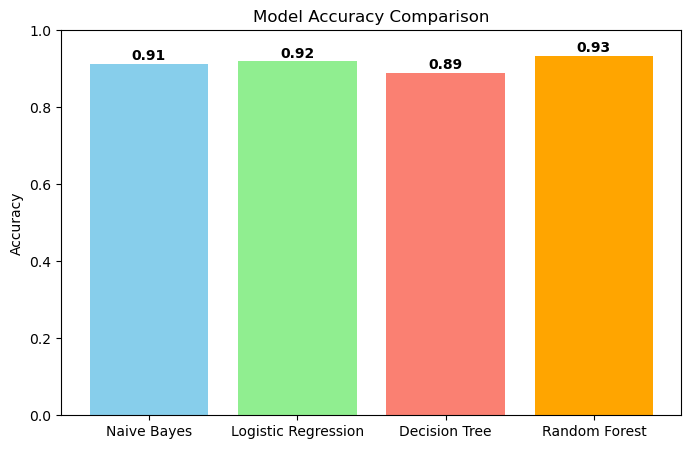

In [59]:
models = ['Naive Bayes', 'Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [accuracy_score(y_test, y_pred_nb),
              accuracy_score(y_test, y_pred_lr),
              accuracy_score(y_test, y_pred_dt),
              accuracy_score(y_test, y_pred_rf)]

# Create bar chart
plt.figure(figsize=(8,5))
plt.bar(models, accuracies, color=['skyblue', 'lightgreen', 'salmon', 'orange'])
plt.ylim(0, 1)  # Accuracy ranges from 0 to 1
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()

In [60]:
print("Logistic Regression Report:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Report:

                 precision    recall  f1-score   support

Negative Review       0.63      0.85      0.73        81
 Neutral Review       0.24      0.29      0.26        31
Positive Review       0.99      0.95      0.97       890

       accuracy                           0.92      1002
      macro avg       0.62      0.70      0.65      1002
   weighted avg       0.93      0.92      0.92      1002



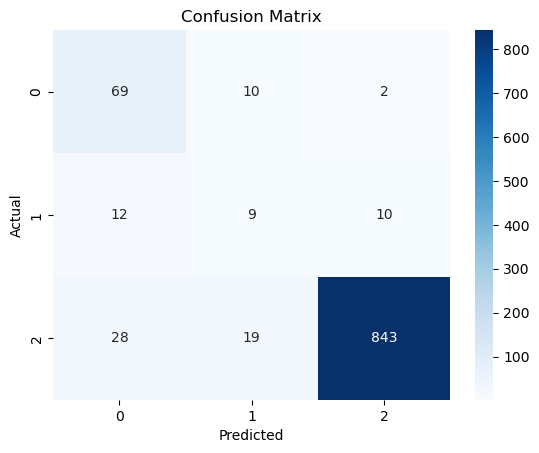

In [61]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# Predictions

In [62]:
def preprocess(text: str) -> str:
    """Lowercase → keep letters & spaces → collapse whitespace."""
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z ]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def _has_phrase(text: str, phrases) -> bool:
    return any(ph in text for ph in phrases)


def _has_word(text: str, word_set: set) -> bool:
    return bool(set(text.split()) & word_set)


def _negated_positive(text: str) -> bool:
    """
    Detects genuinely negative negations like 'not good', 'not worth', 'not happy'.
    Returns True ONLY when a strong positive word is negated — i.e. the reviewer
    is expressing clear dissatisfaction.

    Does NOT return True for:
      "not bad"      — double-negative → neutral/ok
      "not great"    — mild → neutral, not negative
      "not amazing"  — mild → neutral, not negative
      "not perfect"  — mild → neutral, not negative

    Returns True for:
      "not worth"    — clearly negative value judgement
      "not happy"    — clear dissatisfaction
      "not satisfied"— clear dissatisfaction
      "not good"     — clear negative
    """
    # Words that when negated produce a NEUTRAL (not negative) outcome
    MILD_POSITIVE_WORDS = {
        "great", "amazing", "perfect", "excellent", "fantastic",
        "outstanding", "brilliant", "superb", "flawless", "wonderful",
        "bad", "terrible", "awful",  # double-negative = neutral
    }

    # Words that when negated produce a CLEARLY NEGATIVE outcome
    STRONGLY_NEGATION_SENSITIVE = {
        "good", "happy", "satisfied", "pleased", "worth", "recommend",
        "reliable", "durable", "comfortable", "useful", "helpful",
        "effective", "efficient", "working", "works",
    }

    tokens = text.split()
    for i, tok in enumerate(tokens):
        if tok in NEGATION_WORDS and i + 1 < len(tokens):
            nxt = tokens[i + 1]
            # Skip: "not bad/terrible/awful" → neutral double-negative
            # Skip: "not great/amazing/perfect/…" → mild, not strongly negative
            if nxt in MILD_POSITIVE_WORDS:
                continue
            # Only flip to Negative for words where negation = clear dissatisfaction
            if nxt in STRONGLY_NEGATION_SENSITIVE:
                return True
    return False


def is_strongly_negative(text: str) -> bool:
    """
    True if the text has any strong-negative signal:
      • a strong-negative phrase, OR
      • a strong-negative word, OR
      • a negated positive/neutral word
    """
    if _has_phrase(text, STRONG_NEGATIVE_PHRASES):
        return True
    if _has_word(text, STRONG_NEGATIVE_WORDS):
        return True
    if _negated_positive(text):
        return True
    return False


def is_strongly_positive(text: str) -> bool:
    """True if the text has clear positive signals."""
    if _has_phrase(text, STRONG_POSITIVE_PHRASES):
        return True
    hits = sum(1 for w in text.split() if w in STRONG_POSITIVE_WORDS)
    if hits >= 2:
        return True
    return False


def is_product_related(text: str) -> bool:
    """True if text contains at least one product-domain keyword."""
    if set(text.split()) & PRODUCT_KEYWORDS:
        return True
    return False


def is_sentiment_bearing(text: str) -> bool:
    """
    Broader gate — True if the text has ANY sentiment signal at all.
    Allows 'Completely useless' to pass even without a product keyword.

    Special case: exclude generic life-sentiment words ("love", "enjoy", "like")
    when there is no product context — 'i love to play cricket' should stay Invalid.
    """
    if is_strongly_negative(text) or _has_word(text, STRONG_NEGATIVE_WORDS):
        return True
    if _has_phrase(text, STRONG_POSITIVE_PHRASES):
        return True
    if _has_word(text, NEGATIVE_WORDS):
        return True

    # For positive/neutral words, only count them as product-sentiment
    # if combined with a product keyword OR if they are product-specific words
    GENERIC_LIFE_WORDS = {"love", "loved", "enjoy", "enjoyed", "like", "liked",
                          "happy", "sad", "fun", "exciting", "beautiful", "nice"}
    product_positive = POSITIVE_WORDS - GENERIC_LIFE_WORDS
    if _has_word(text, product_positive):
        return True

    # Generic positive words only count if there's also a product keyword nearby
    if _has_word(text, GENERIC_LIFE_WORDS) and is_product_related(text):
        return True

    if _has_word(text, NEUTRAL_WORDS) or _has_phrase(text, NEUTRAL_PHRASES):
        return True

    return False


def is_weak_neutral(text: str) -> bool:
    """
    True when the text contains mild/neutral language AND no strong negative signal.

    Handles:
      "not bad, not great either"          → Neutral (soft double-negation)
      "decent quality, not amazing though" → Neutral (decent + mild not-amazing)
      "fine but nothing special"           → Neutral
      "bad product"                        → NOT neutral (hard negative word)
    """
    # Hard negative single words that disqualify (only when NOT preceded by negation)
    HARD_NEGATIVE = STRONG_NEGATIVE_WORDS | {
        "poor", "broken", "defective", "faulty", "failure",
        "fail", "failed", "disappointing", "disappointed", "frustrating",
    }

    # Check for hard negative words, but ignore "bad" when it's part of "not bad"
    tokens = text.split()
    for i, tok in enumerate(tokens):
        if tok in HARD_NEGATIVE:
            # Allow "bad" if preceded by "not" → "not bad" = neutral
            if tok == "bad" and i > 0 and tokens[i - 1] == "not":
                continue
            return False

    # Strong negative phrases disqualify
    if _has_phrase(text, STRONG_NEGATIVE_PHRASES):
        return False

    # Genuine negative negation (e.g. "not happy", "not worth") disqualifies
    if _negated_positive(text):
        return False

    # Mild negations like "not amazing", "not great", "not perfect" → still neutral
    MILD_NEGATED_POSITIVE = ["not amazing", "not great", "not perfect",
                              "not excellent", "not fantastic", "not outstanding"]

    has_neutral_word   = _has_word(text, NEUTRAL_WORDS)
    has_neutral_phrase = _has_phrase(text, NEUTRAL_PHRASES)
    has_not_bad        = "not bad" in text
    has_mild_neg       = _has_phrase(text, MILD_NEGATED_POSITIVE)

    return has_neutral_word or has_neutral_phrase or has_not_bad or has_mild_neg


def is_confident(text: str, threshold: float = 0.60) -> bool:
    """True if the ML model's top class probability > threshold."""
    vec   = tfidf.transform([text])
    probs = lr_model.predict_proba(vec)[0]
    return max(probs) > threshold


def keyword_sentiment(text: str):
    """Keyword-only fallback. Returns label string or None."""
    if is_strongly_negative(text) or _has_word(text, NEGATIVE_WORDS):
        return "Negative Review"
    if is_strongly_positive(text) or _has_word(text, POSITIVE_WORDS):
        return "Positive Review"
    if is_weak_neutral(text):
        return "Neutral Review"
    return None


# ─────────────────────────────────────────────────────────────────────────────
# MAIN PREDICTION FUNCTION
# ─────────────────────────────────────────────────────────────────────────────

def predict_sentiment(review: str) -> str:
    """
    Classifies a review as:
        "Positive Review" | "Negative Review" | "Neutral Review" | "Invalid Review"
    """

    # 1. Preprocess
    clean = preprocess(review)

    # 2. Empty / too short
    if len(clean.split()) < 2:
        return "Invalid Review"

    # 3. Strong-negative guard — HIGHEST priority
    #    Catches: "Waste of money", "Completely useless",
    #             "Not worth the price", "I hate this product"
    if is_strongly_negative(clean):
        return "Negative Review"

    # 4. Strong-positive guard
    if is_strongly_positive(clean):
        return "Positive Review"

    # 5. Off-topic / random sentence filter
    #    Reject only when there is ZERO product signal AND ZERO sentiment signal
    #    "my name is devansh", "i love to play cricket" → Invalid
    if not is_product_related(clean) and not is_sentiment_bearing(clean):
        return "Invalid Review"

    # 6. Weak / neutral catch (only when no negative word present)
    #    "The device works fine but nothing special" → Neutral
    if is_weak_neutral(clean):
        return "Neutral Review"

    # 7. ML model
    vec        = tfidf.transform([clean])
    prediction = str(lr_model.predict(vec)[0])

    # 8. Low-confidence fallback to keywords
    if not is_confident(clean, threshold=0.60):
        kw = keyword_sentiment(clean)
        if kw:
            return kw

    # 9. Normalise ML label
    pred_lower = prediction.lower()
    if "positive" in pred_lower:
        return "Positive Review"
    if "negative" in pred_lower:
        return "Negative Review"
    if "neutral"  in pred_lower:
        return "Neutral Review"

    # Final fallback: keyword or neutral
    return keyword_sentiment(clean) or "Neutral Review"


In [63]:
print(predict_sentiment(
    "The product has poor performance and many issues"
))

print(predict_sentiment(
    "The device quality is excellent and performance is impressive"
))

print(predict_sentiment(
    "i love cricket"
))

print(predict_sentiment(
    "fgjnfjgnfjgno516545"
))

Negative Review
Positive Review
Invalid Review
Invalid Review


In [119]:
print(np.unique(y_pred_lr, return_counts=True))

(array(['Negative Review', 'Neutral Review', 'Positive Review'],
      dtype=object), array([108,  39, 855]))


In [64]:
test_reviews = [
    "Absolutely love it! Would definitely buy again.",
    "Waste of money. Very poor build quality.",
    "Fantastic purchase, highly recommend it to everyone!",
    "The product is durable and performance is average and provides great value for money",
    "The device stopped working and the experience was disappointing",
    "The overall performance is decent but could be better",
    "The quality is excellent and customer satisfaction is high",
    "The product has several issues and does not meet expectations",
    "wow amazing! phone is died in two days",
    "i love this product",
    "fbgsgbs"
]

for r in test_reviews:
    print(r, "→", predict_sentiment(r))

Absolutely love it! Would definitely buy again. → Positive Review
Waste of money. Very poor build quality. → Negative Review
Fantastic purchase, highly recommend it to everyone! → Positive Review
The product is durable and performance is average and provides great value for money → Positive Review
The device stopped working and the experience was disappointing → Negative Review
The overall performance is decent but could be better → Neutral Review
The quality is excellent and customer satisfaction is high → Positive Review
The product has several issues and does not meet expectations → Negative Review
wow amazing! phone is died in two days → Positive Review
i love this product → Positive Review
fbgsgbs → Invalid Review


In [65]:
test_reviews = [
    "The product offers excellent performance and battery life is impressive",
    "The device has poor quality and many issues with functionality",
    "I am very disappointed. It stopped working after two days.",
    "The design is good but performance is average",
    "The product is durable and performance is average and provides great value for money",
    "The device stopped working and the experience was disappointing",
    "The overall performance is decent but could be better",
    "The quality is excellent and customer satisfaction is high",
    "The product has several issues and does not meet expectations"
]

for r in test_reviews:
    print(r, "→", predict_sentiment(r))

The product offers excellent performance and battery life is impressive → Positive Review
The device has poor quality and many issues with functionality → Negative Review
I am very disappointed. It stopped working after two days. → Negative Review
The design is good but performance is average → Neutral Review
The product is durable and performance is average and provides great value for money → Positive Review
The device stopped working and the experience was disappointing → Negative Review
The overall performance is decent but could be better → Neutral Review
The quality is excellent and customer satisfaction is high → Positive Review
The product has several issues and does not meet expectations → Negative Review


In [47]:
test_reviews = [
    "The product offers excellent performance and battery life is impressive",
    "The device has poor quality and many issues with functionality",
    "The design is good but performance is average",
    "The product is durable and performance is average and provides great value for money",
    "The device stopped working and the experience was disappointing",
    "The overall performance is decent but could be better",
    "The quality is excellent and customer satisfaction is high",
    "The product has several issues and does not meet expectations"
]

for r in test_reviews:
    print(r, "→", predict_sentiment(r))

The product offers excellent performance and battery life is impressive → Positive Review
The device has poor quality and many issues with functionality → Negative Review
The design is good but performance is average → Neutral Review
The product is durable and performance is average and provides great value for money → Neutral Review
The device stopped working and the experience was disappointing → Negative Review
The overall performance is decent but could be better → Neutral Review
The quality is excellent and customer satisfaction is high → Positive Review
The product has several issues and does not meet expectations → Negative Review


In [142]:
print(predict_sentiment(
    "The product performance is okay"
))

print(predict_sentiment(
    "The device works fine but nothing special"
))

Invalid
Neutral Review


In [66]:
test_reviews = [
    # Positive
    "The product offers excellent performance and battery life is impressive",
    "The device quality is amazing and I am very satisfied with the purchase",

    # Negative
    "The product has poor quality and many issues with performance",
    "The device stopped working and the experience was disappointing",

    # Neutral
    "The product is average and performance is okay",
    "The device works fine but nothing special"
]

for review in test_reviews:
    print(review)
    print("Prediction:", predict_sentiment(review))
    print("------")

The product offers excellent performance and battery life is impressive
Prediction: Positive Review
------
The device quality is amazing and I am very satisfied with the purchase
Prediction: Positive Review
------
The product has poor quality and many issues with performance
Prediction: Negative Review
------
The device stopped working and the experience was disappointing
Prediction: Negative Review
------
The product is average and performance is okay
Prediction: Neutral Review
------
The device works fine but nothing special
Prediction: Neutral Review
------


In [67]:
import pickle

# Save model
pickle.dump(lr_model, open('sentiment_model4.pkl', 'wb'))

# Save vectorizer
pickle.dump(tfidf, open('vectorizer4.pkl', 'wb'))